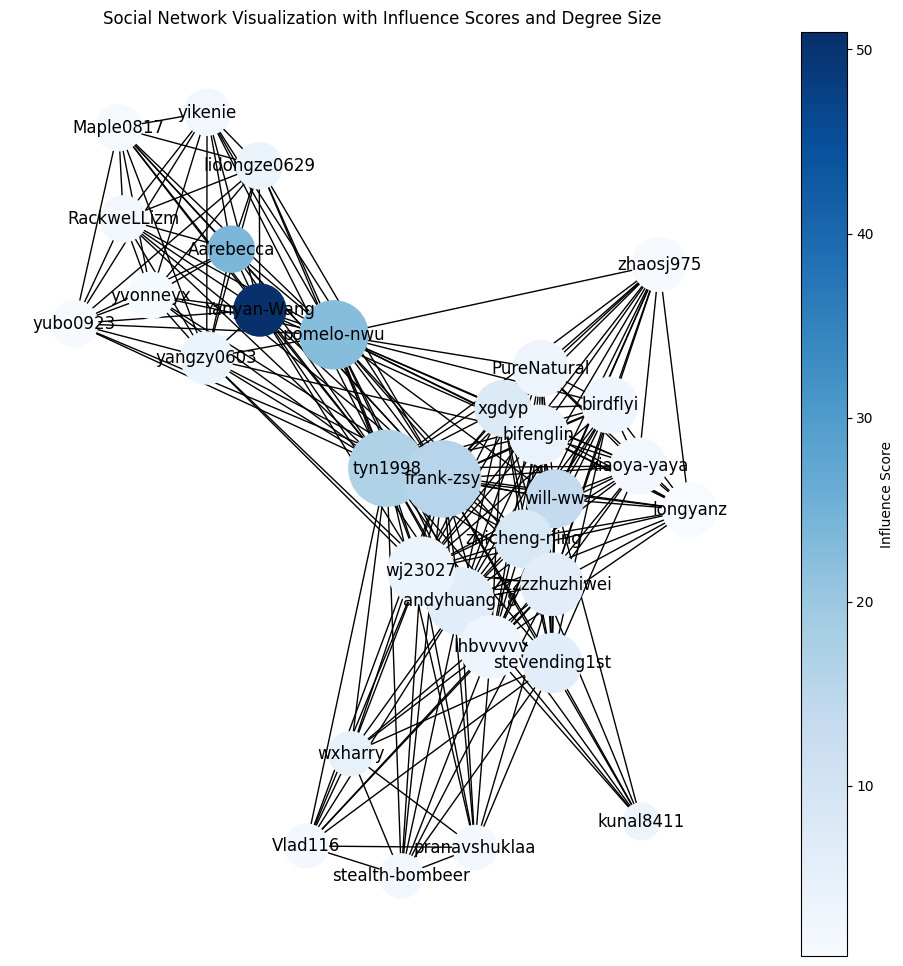

1. 每个用户的直接朋友: {'Yanyan-Wang': ['Aarebecca', 'pomelo-nwu', 'yangzy0603', 'tyn1998', 'yvonneyx', 'lidongze0629', 'RackweLLizm', 'yikenie', 'yubo0923', 'Maple0817', 'wj23027', 'frank-zsy', 'andyhuang18', 'bifenglin'], 'Aarebecca': ['Yanyan-Wang', 'pomelo-nwu', 'yangzy0603', 'yvonneyx', 'lidongze0629', 'tyn1998', 'RackweLLizm', 'yikenie', 'yubo0923', 'Maple0817', 'frank-zsy'], 'pomelo-nwu': ['Yanyan-Wang', 'Aarebecca', 'yangzy0603', 'tyn1998', 'lidongze0629', 'yvonneyx', 'RackweLLizm', 'yikenie', 'bifenglin', 'frank-zsy', 'yubo0923', 'wj23027', 'andyhuang18', 'Maple0817', 'will-ww', 'zhicheng-ning', 'PureNatural', 'xiaoya-yaya', 'xgdyp', 'longyanz', 'Zzzzzhuzhiwei', 'birdflyi', 'lhbvvvvv', 'zhaosj975'], 'tyn1998': ['andyhuang18', 'pomelo-nwu', 'frank-zsy', 'wj23027', 'bifenglin', 'Yanyan-Wang', 'will-ww', 'Zzzzzhuzhiwei', 'lhbvvvvv', 'zhicheng-ning', 'PureNatural', 'yangzy0603', 'xgdyp', 'stevending1st', 'wxharry', 'Aarebecca', 'birdflyi', 'xiaoya-yaya', 'pranavshuklaa', 'lidongze0629', 'y

In [13]:
import json
import networkx as nx
import matplotlib.pyplot as plt
from operator import itemgetter

with open('hw4_data.json', 'r') as file:
    data = json.load(file)


nodes_data = data['nodes']
edges_data = data['edges']


G = nx.Graph()


for node in nodes_data:
    G.add_node(node[0], influence_score=node[1])

for edge in edges_data:
    G.add_edge(edge[0], edge[1], weight=edge[2])

direct_friends = {node: list(G.neighbors(node)) for node in G.nodes()}

degree_centrality = {node: len(friends) for node, friends in direct_friends.items()}
top_5_degree = sorted(degree_centrality.items(), key=itemgetter(1), reverse=True)[:5]

influence_scores = {node[0]: node[1] for node in nodes_data}
top_5_influence = sorted(influence_scores.items(), key=itemgetter(1), reverse=True)[:5]

combined_scores = {node: 0.5 * influence_scores[node] + 0.5 * degree_centrality[node] for node in G.nodes()}
top_5_combined = sorted(combined_scores.items(), key=itemgetter(1), reverse=True)[:5]

yanyan_friends = set(direct_friends['Yanyan-Wang'])
friends_of_friends = set()
for friend in yanyan_friends:
    friends_of_friends.update(direct_friends[friend])


friends_of_friends -= yanyan_friends
recommendations = sorted([(fof, len(set(direct_friends[fof]) & yanyan_friends)) for fof in friends_of_friends], key=itemgetter(1), reverse=True)


yanyan_connections = [(neighbor, G['Yanyan-Wang'][neighbor]['weight']) for neighbor in G.neighbors('Yanyan-Wang')]
top_5_connections = sorted(yanyan_connections, key=itemgetter(1), reverse=True)[:5]


fig, ax = plt.subplots(figsize=(12, 12))  
pos = nx.spring_layout(G)


node_colors = [G.nodes[node]['influence_score'] for node in G.nodes()]
nx.draw(G, pos, node_size=[degree_centrality[node] * 100 for node in G.nodes()],
        node_color=node_colors, cmap=plt.cm.Blues, with_labels=True, ax=ax)  # 指定坐标轴


sm = plt.cm.ScalarMappable(cmap=plt.cm.Blues, norm=plt.Normalize(vmin=min(node_colors), vmax=max(node_colors)))
sm.set_array([])  
plt.colorbar(sm, ax=ax, label="Influence Score")  
plt.title("Social Network Visualization with Influence Scores and Degree Size")
plt.show()


print("1. 每个用户的直接朋友:", direct_friends)
print("2. 度数最高的前5个用户:", top_5_degree)
print("3. 影响力分数最高的前5个用户:", top_5_influence)
print("4. 综合影响力分数和朋友数量排名的前5个用户:", top_5_combined)
print("5. 基于共同朋友为 Yanyan-Wang 推荐的新朋友:", recommendations)
print("6. 与 Yanyan-Wang 连接强度最高的前5个用户:", top_5_connections)
